Go to this link, at your lat long, copy the url at the bottom and lazy load it here: http://thredds.northwestknowledge.net:8080/thredds/ncss/grid/agg_terraclimate_tmin_1958_CurrentYear_GLOBE.nc/dataset.html

<h1>ISLAMABAD</h1>

In [1]:
import geopandas
import rioxarray
import xarray as xr
from geojson import Feature, FeatureCollection


In [ ]:
ds_min = xr.open_dataset("http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_terraclimate_tmin_1958_CurrentYear_GLOBE.nc")
#ds_max = xr.open_dataset("http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_terraclimate_tmax_1958_CurrentYear_GLOBE.nc")


C:\Users\hiban\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\backends\api.py:577: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
C:\Users\hiban\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\backends\api.py:577: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


In [94]:
print(ds_min)

<xarray.Dataset> Size: 240GB
Dimensions:  (time: 804, lat: 4320, lon: 8640, crs: 1)
Coordinates:
  * crs      (crs) int16 2B 3
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2024-12-01
Data variables:
    tmin     (time, lat, lon) float64 240GB ...
Attributes: (12/49)
    method:                          These layers from TerraClimate were crea...
    title:                           TerraClimate: monthly climate and climat...
    summary:                         This archive contains a dataset of high-...
    keywords:                        WORLDCLIM,global,monthly, temperature,pr...
    id:                              Blank
    naming_authority:                edu.uidaho.nkn
    ...                              ...
    geospatial_vertical_resolution:  0.0
    geospatial_vertical_positive:    Up
    references:   

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Function to add mean and trend line
def add_mean_trend(ax, series, color_mean='red', color_trend='green', label_prefix=''):
    # Mean line
    mean_val = series.mean()
    ax.axhline(y=mean_val, color=color_mean, linestyle='--', linewidth=2, label=f'{label_prefix} Mean: {mean_val:.2f}°C')
    
    # Trend line
    x_numeric = np.arange(len(series))
    slope, intercept, r_value, p_value, std_err = linregress(x_numeric, series.values)
    trend_line = intercept + slope * x_numeric
    ax.plot(series.index, trend_line, color=color_trend, linestyle='-', linewidth=2, label=f'{label_prefix} Trend: {slope:.4f} °C/day')



In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


# Define Islamabad bounding box
lat_min, lat_max = 33, 34
lon_min, lon_max = 72, 74

# Subset spatially
tmin_isl = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# Subset time: 1960 onward
tmin_isl = tmin_isl.sel(time=slice('1960-01-01', None))

# Compute daily average over all grid points
tmin_monthly = tmin_isl.mean(dim=['lat','lon'])

# Convert to pandas for easier handling
tmin_monthly = tmin_monthly.to_pandas()





<h1>4 Samples</h1>

In [ ]:
# Define Muhrain bounding box
lat_min, lat_max = 33.666667, 33.70831
lon_min, lon_max = 73.16667, 73.208333

# Subset spatially
tmin_muhrain = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))


# Subset time: 1960 onward
tmin_muhrain = tmin_muhrain.sel(time=slice('1960-01-01', None))

# Compute daily average over all grid points
tmin_muhrain_monthly = tmin_muhrain.mean(dim=['lat','lon'])

# Convert to pandas for easier handling
tmin_muhrain_monthly = tmin_muhrain_monthly.to_pandas()

C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\2873837553.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tmin_muhrain_monthly = tmin_muhrain_daily_series.resample('M').mean()


In [ ]:
# Define i9 bounding box
lat_min, lat_max = 33.62506, 33.66655
lon_min, lon_max = 73.04179, 73.08328

# Subset spatially
tmin_i9 = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# Subset time: 1960 onward
tmin_i9 = tmin_i9.sel(time=slice('1960-01-01', None))

# Compute daily average over all grid points
tmin_i9_monthly = tmin_i9.mean(dim=['lat','lon'])

# Convert to pandas for easier handling
tmin_i9_monthly = tmin_i9_monthly.to_pandas()

C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\741185068.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tmin_i9_monthly = tmin_i9_daily_series.resample('M').mean()


In [ ]:
# Define jangal bounding box
lat_min, lat_max = 33.5417, 33.5831
lon_min, lon_max = 72.7504, 72.7916

# Subset spatially
tmin_jangal = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# Subset time: 1960 onward
tmin_jangal = tmin_jangal.sel(time=slice('1960-01-01', None))

# Compute daily average over all grid points
tmin_jangal_monthly = tmin_jangal.mean(dim=['lat','lon'])

# Convert to pandas for easier handling
tmin_jangal_monthly = tmin_jangal_monthly.to_pandas()



C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\918901715.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tmin_jangal_monthly = tmin_jangal_daily_series.resample('M').mean()


In [ ]:
# Define margalla bounding box
lat_min, lat_max = 33.75006, 33.79148
lon_min, lon_max = 73.08356, 73.12499

# Subset spatially
tmin_margalla = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# Subset time: 1960 onward
tmin_margalla= tmin_margalla.sel(time=slice('1960-01-01', None))

# Compute daily average over all grid points
tmin_margalla_monthly = tmin_margalla.mean(dim=['lat','lon'])

# Convert to pandas for easier handling
tmin_margalla_monthly = tmin_margalla_monthly.to_pandas()




C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\2008598997.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tmin_margalla_monthly = tmin_margalla_daily_series.resample('M').mean()


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_monthly_annual_comparison(series_dict):
    """
    series_dict: dict
        Example: {
            "Urban": tmin_urban_series,
            "Rural": tmin_rural_series,
            "Jangal": tmin_jangal_series
        }
    """

    # Prepare color and linestyle cycling for combined plot
    colors = ["blue", "red", "green", "purple", "orange", "brown", "cyan", "magenta"]
    linestyles = ["-", "--", "-.", ":", (0, (5,1)), (0, (3,5,1,5)), (0, (1,1))]
    
    # --- Precompute monthly & annual ---
    monthly_dict = {}
    annual_dict = {}
    
    for name, ser in series_dict.items():
        monthly = ser.resample('M').mean()
        annual = ser.resample('Y').mean()

        monthly_dict[name] = monthly
        annual_dict[name] = annual

    # -----------------------
    #     INDIVIDUAL MONTHLY
    # -----------------------
    n = len(series_dict)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, (name, ser) in zip(axes, monthly_dict.items()):
        
        # Main plot
        ax.plot(ser.index, ser, label=f"{name} Monthly", linewidth=1.5)

        # Mean line
        mean_val = ser.mean()
        ax.axhline(mean_val, linestyle='--',
                   label=f"Mean: {mean_val:.2f}°C")

        # Trend line + slope
        valid = ser.dropna()
        x = valid.index.map(pd.Timestamp.toordinal)
        y = valid.values
        slope, intercept, _, _, _ = linregress(x, y)
        trend = intercept + slope * x
        slope_decade = slope * 365.25 * 10  # °C per decade

        ax.plot(valid.index, trend, linewidth=2,
                label=f"Trend (slope={slope_decade:.3f}°C/dec)")

        ax.set_title(f"{name} — Monthly Tmin", fontsize=14)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    # -----------------------
    #     INDIVIDUAL ANNUAL
    # -----------------------
    fig, axes = plt.subplots(n, 1, figsize=(14, 4*n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, (name, ser) in zip(axes, annual_dict.items()):
        
        # Main plot
        ax.plot(ser.index, ser, label=f"{name} Annual", linewidth=1.5)

        # Mean line
        mean_val = ser.mean()
        ax.axhline(mean_val, linestyle='--',
                   label=f"Mean: {mean_val:.2f}°C")

        # Trend line + slope
        valid = ser.dropna()
        x = valid.index.map(pd.Timestamp.toordinal)
        y = valid.values
        slope, intercept, _, _, _ = linregress(x, y)
        trend = intercept + slope * x
        slope_decade = slope * 365.25 * 10  # °C per decade

        ax.plot(valid.index, trend, linewidth=2,
                label=f"Trend (slope={slope_decade:.3f}°C/dec)")

        ax.set_title(f"{name} — Annual Tmin", fontsize=14)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    #        COLLECTIVE MONTHLY COMPARISON
    # ---------------------------------------------------
    plt.figure(figsize=(16, 7))

    for i, (name, ser) in enumerate(monthly_dict.items()):
        color = colors[i % len(colors)]
        style = linestyles[i % len(linestyles)]

        valid = ser.dropna()
        x = valid.index.map(pd.Timestamp.toordinal)
        y = valid.values
        slope, intercept, _, _, _ = linregress(x, y)
        trend = intercept + slope * x
        slope_decade = slope * 365.25 * 10

        # Main
        plt.plot(ser.index, ser, linewidth=2, color=color, linestyle=style,
                 label=f"{name} Monthly (trend={slope_decade:.3f}°C/dec)")

        # Trend
        plt.plot(valid.index, trend, linestyle="--", color=color, linewidth=1.8)

    plt.title("Monthly Tmin Comparison — All Locations", fontsize=16)
    plt.xlabel("Year")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    #        COLLECTIVE ANNUAL COMPARISON
    # ---------------------------------------------------
    plt.figure(figsize=(16, 7))

    for i, (name, ser) in enumerate(annual_dict.items()):
        color = colors[i % len(colors)]
        style = linestyles[i % len(linestyles)]

        valid = ser.dropna()
        x = valid.index.map(pd.Timestamp.toordinal)
        y = valid.values
        slope, intercept, _, _, _ = linregress(x, y)
        trend = intercept + slope * x
        slope_decade = slope * 365.25 * 10

        # Main
        plt.plot(ser.index, ser, linewidth=2, color=color, linestyle=style,
                 label=f"{name} Annual (trend={slope_decade:.3f}°C/dec)")

        # Trend
        plt.plot(valid.index, trend, linestyle="--", color=color, linewidth=1.8)

    plt.title("Annual Tmin Comparison — All Locations", fontsize=16)
    plt.xlabel("Year")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\2627860977.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ser.resample('M').mean()
C:\Users\hiban\AppData\Local\Temp\ipykernel_20840\2627860977.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = ser.resample('Y').mean()


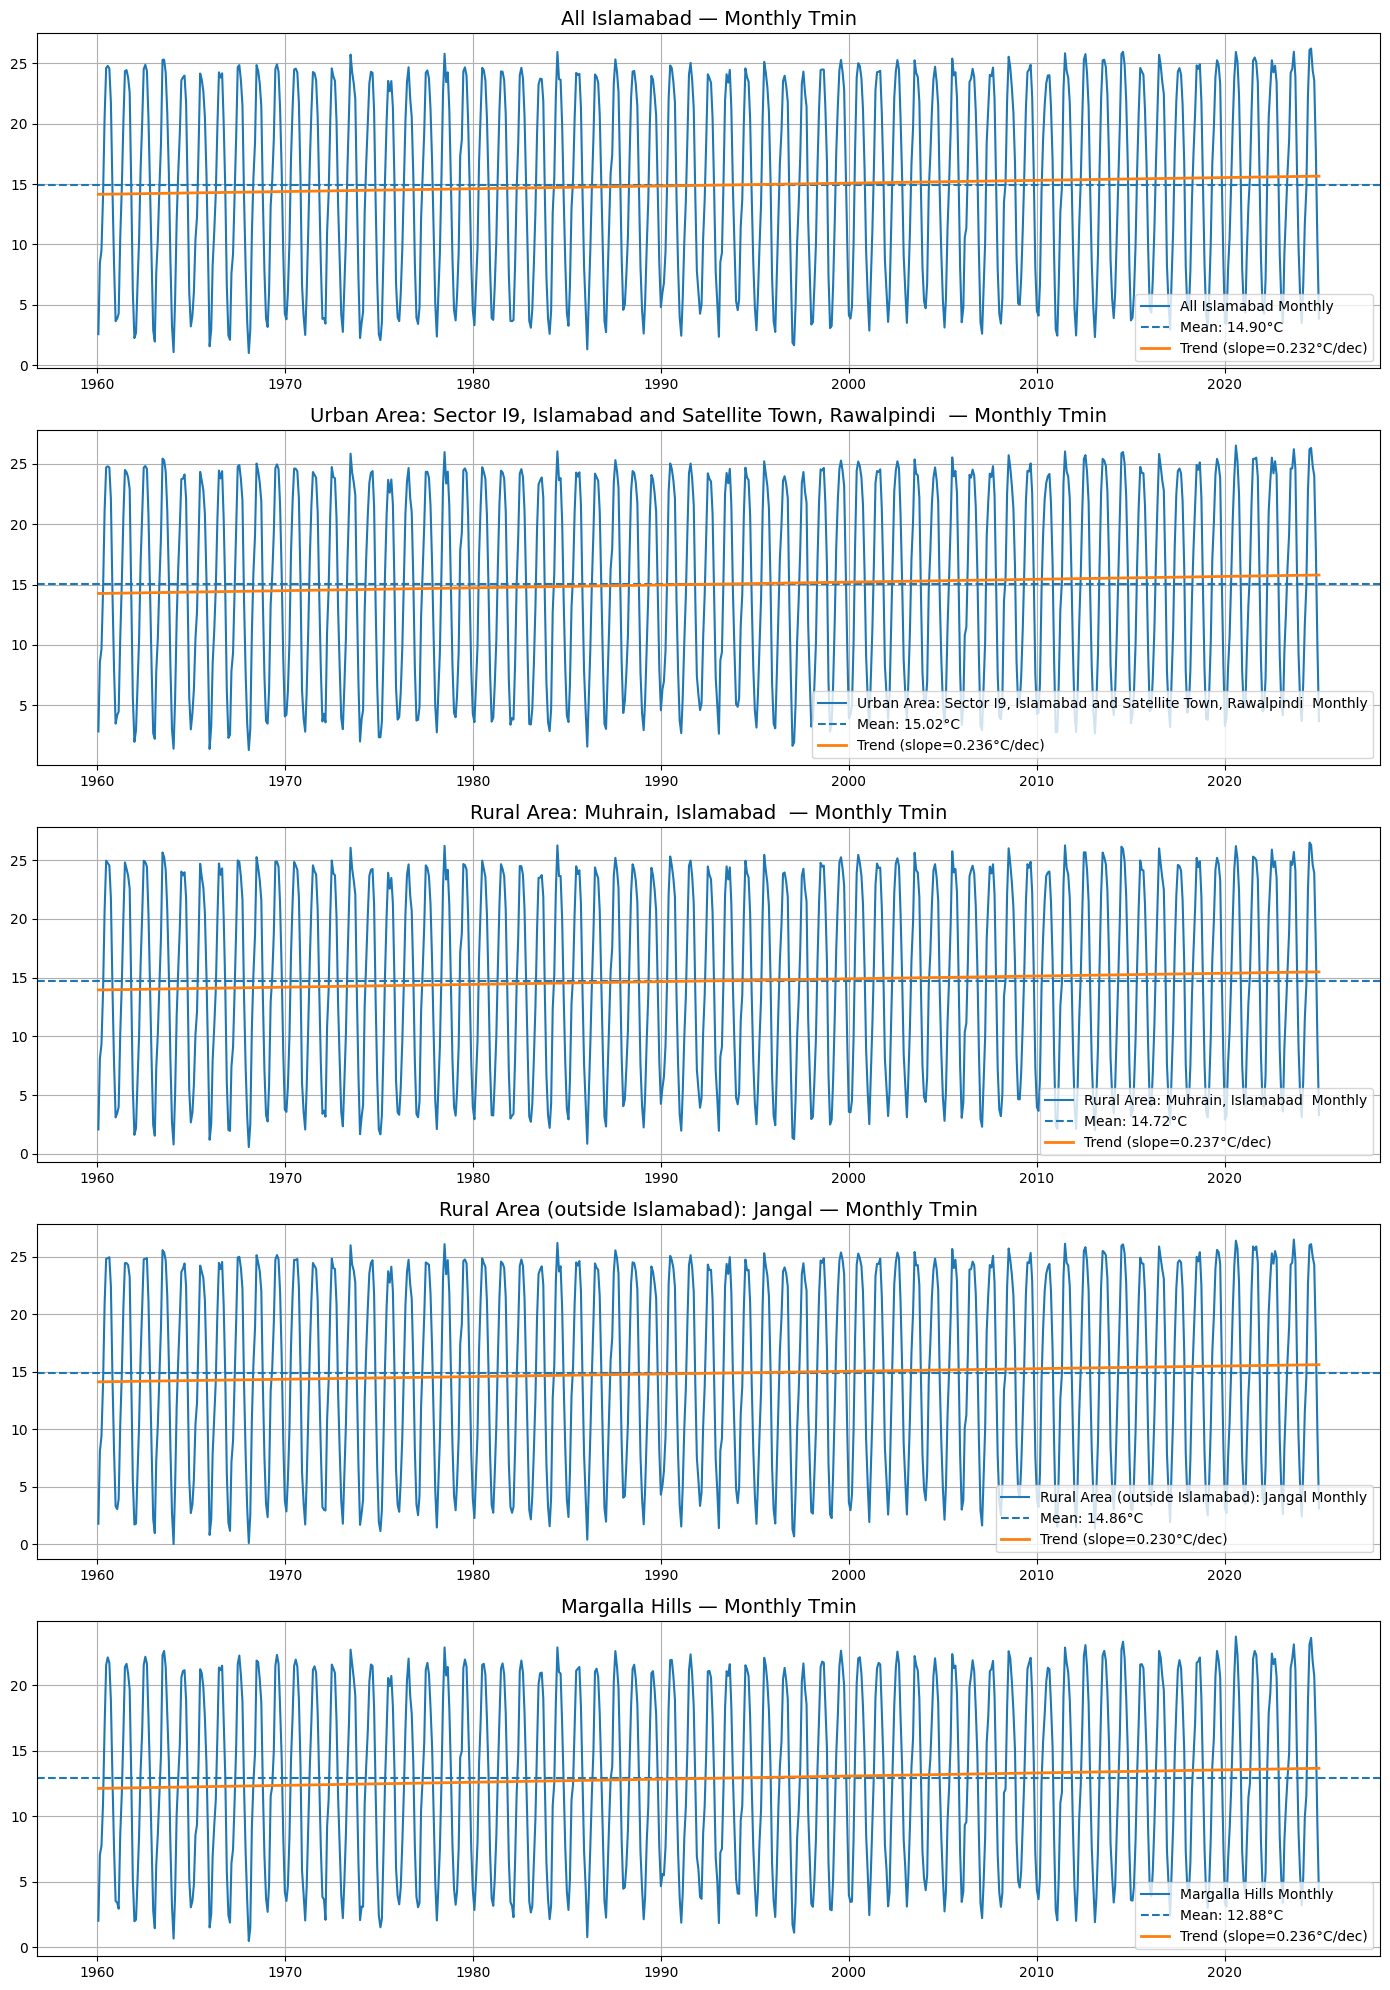

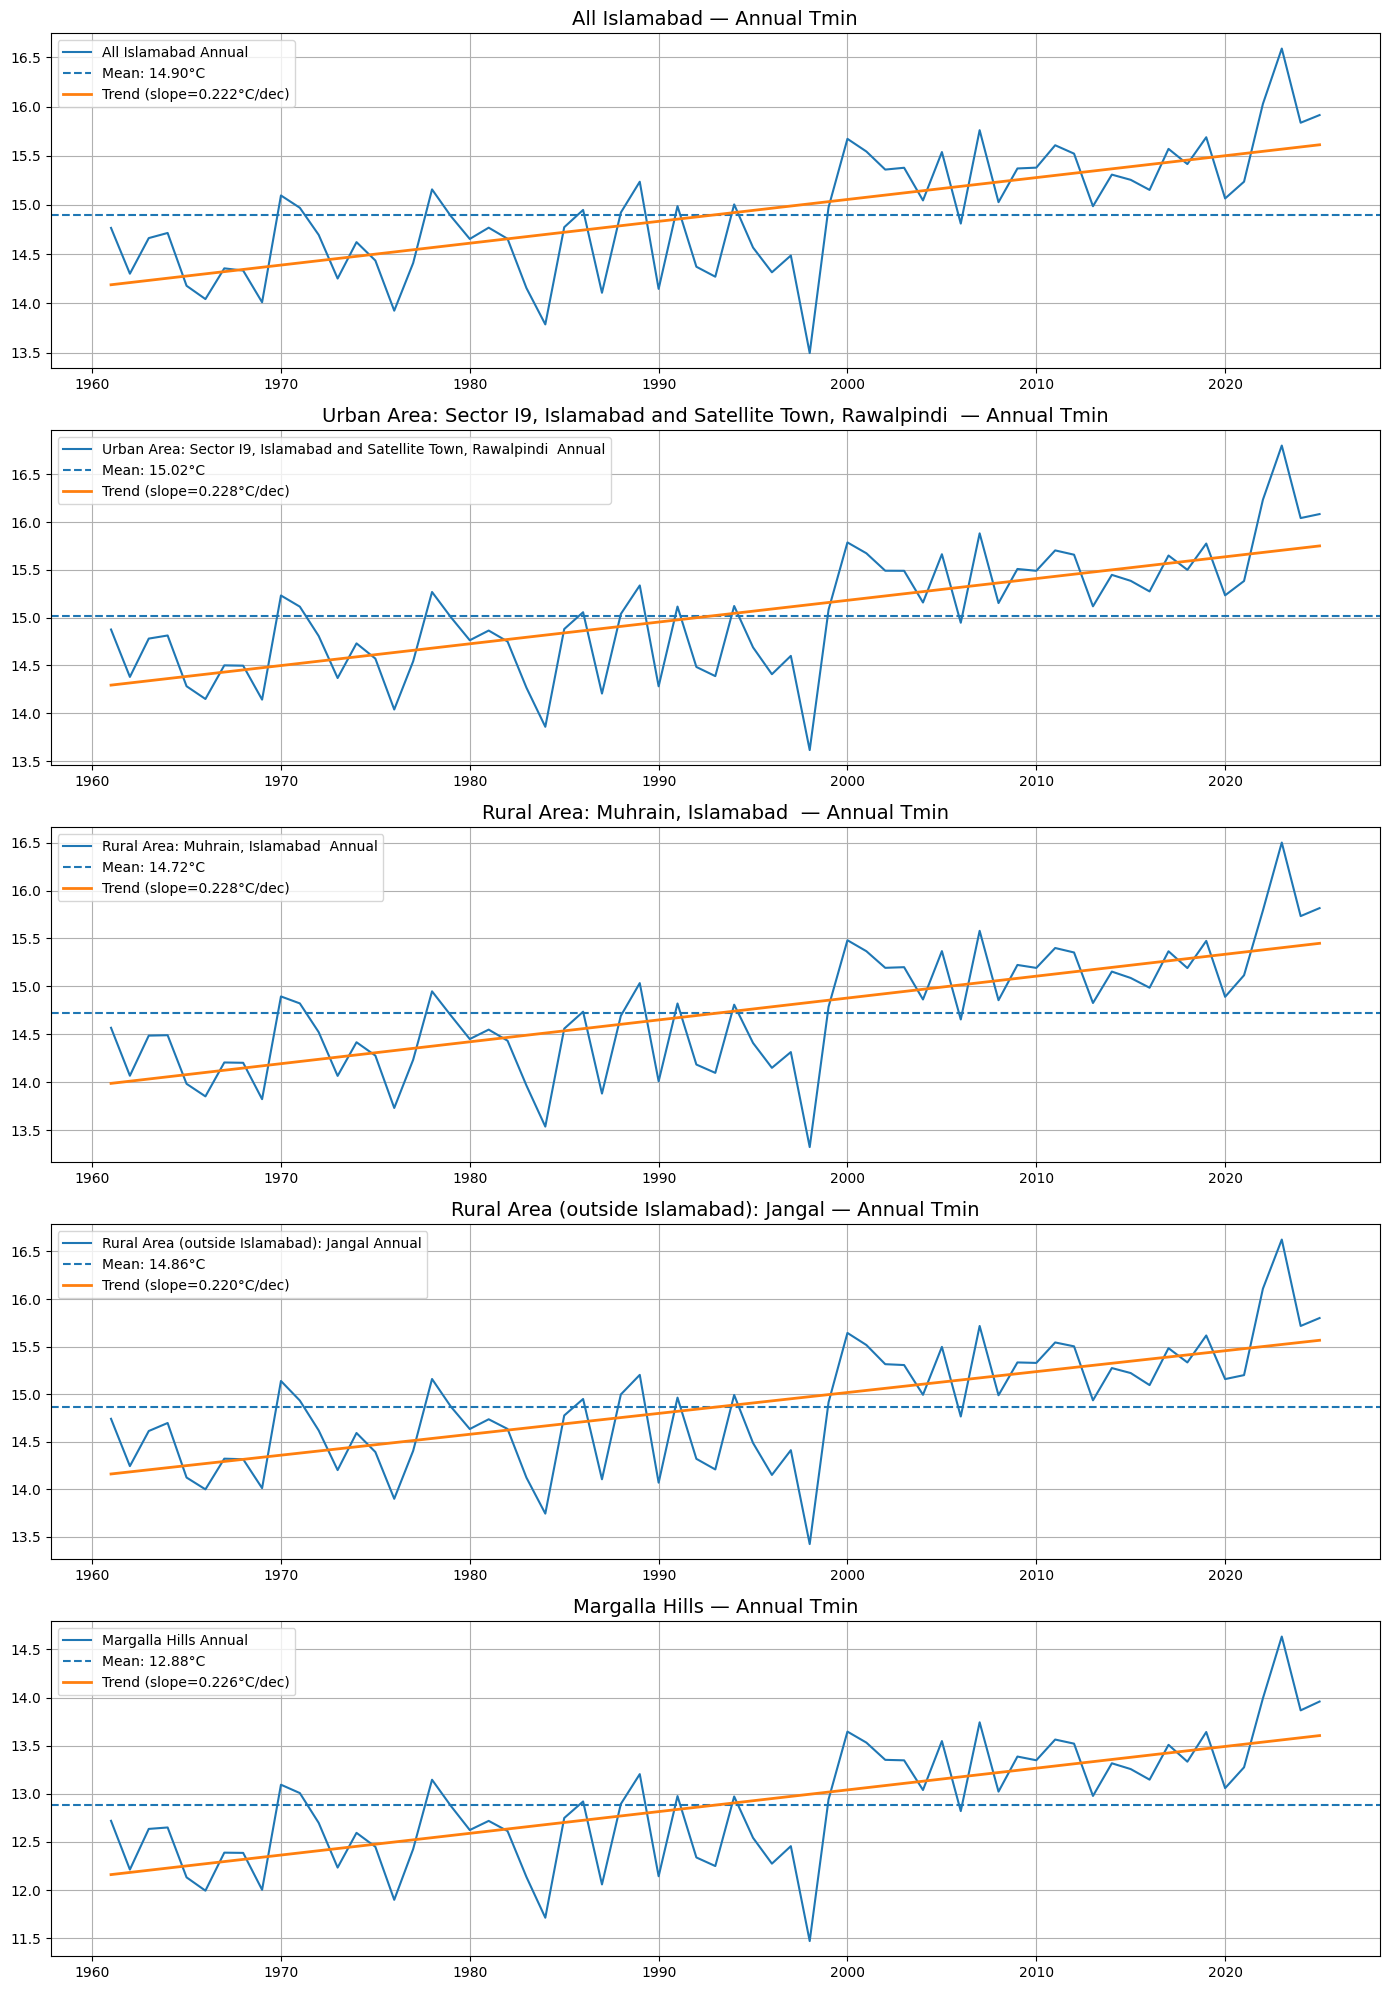

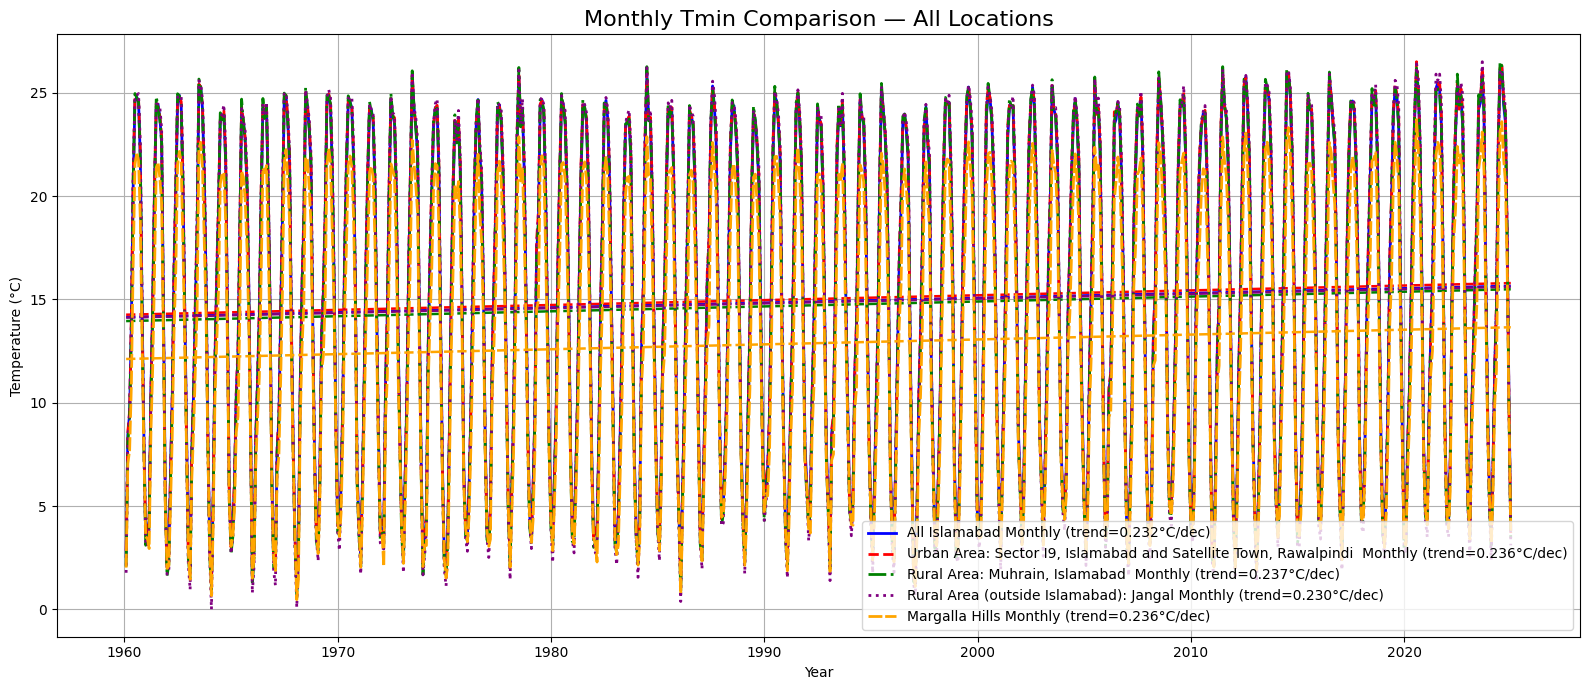

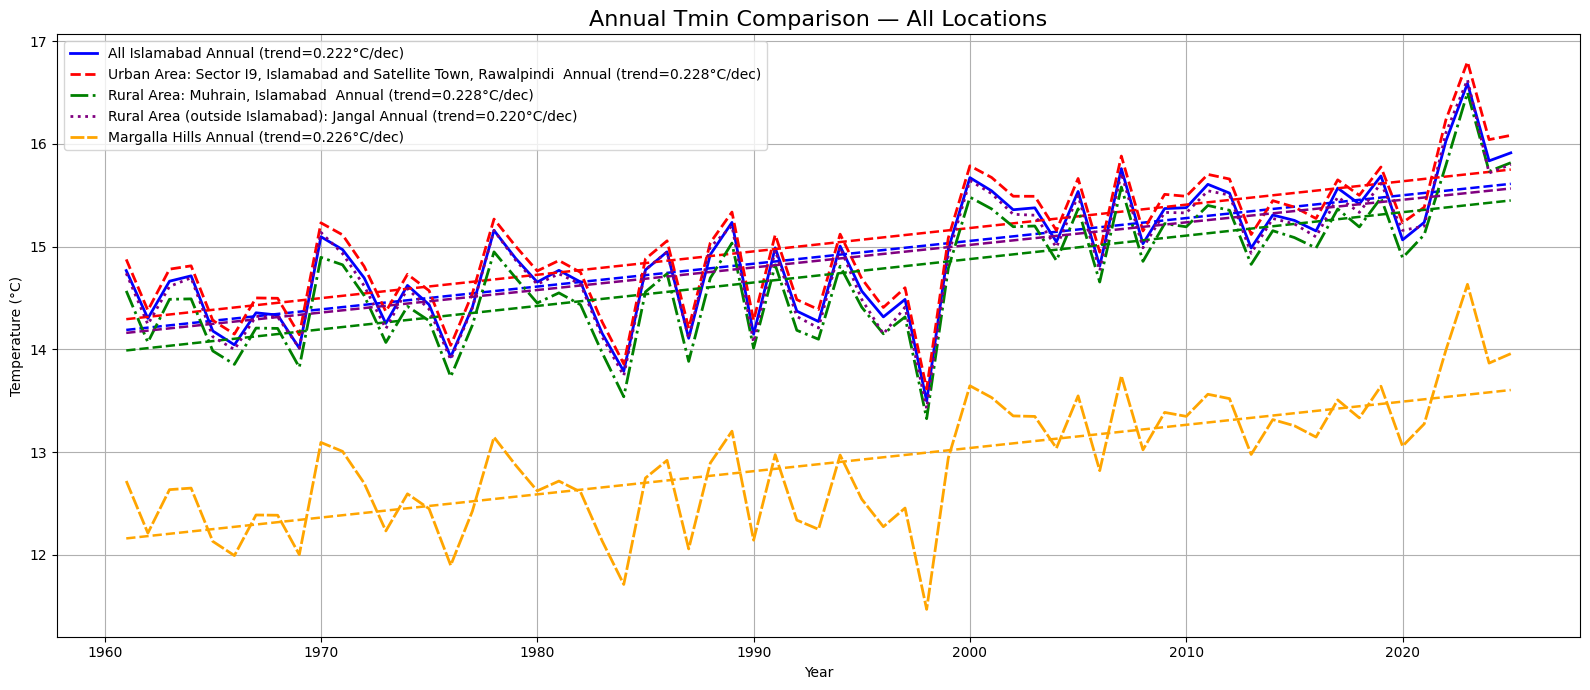

In [95]:
plot_monthly_annual_comparison({
    "All Islamabad": tmin_monthly,
    "Urban Area: Sector I9, Islamabad and Satellite Town, Rawalpindi ": tmin_i9_monthly,
    "Rural Area: Muhrain, Islamabad ": tmin_muhrain_monthly,
    "Rural Area (outside Islamabad): Jangal": tmin_jangal_monthly,
    "Margalla Hills": tmin_margalla_monthly
})


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_series_with_trend(series, title="Time Series", ylabel="Value", xlabel="Time"):
    """
    Plots a pandas Series with mean line and linear trend line.
    
    Parameters:
    -----------
    series : pd.Series
        Series with datetime index.
    title : str
        Plot title.
    ylabel : str
        Y-axis label.
    xlabel : str
        X-axis label.
    """
    series = series.dropna()
    
    # Mean
    mean_val = series.mean()
    
    # Linear trend
    x = series.index.map(pd.Timestamp.toordinal)  # convert to numeric
    y = series.values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Convert slope to °C per decade
    slope_decade = slope * 365.25 * 10
    
    trend = intercept + slope * x
    
    # Plotting
    plt.figure(figsize=(12,5))
    plt.plot(series.index, y, label="Data", linewidth=1.5)
    plt.axhline(mean_val, color='red', linestyle='--', linewidth=1.8, label=f"Mean = {mean_val:.2f}")
    plt.plot(series.index, trend, color='green', linestyle='--', linewidth=2, label=f"Trend = {slope_decade:.3f} °C/dec")
    
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


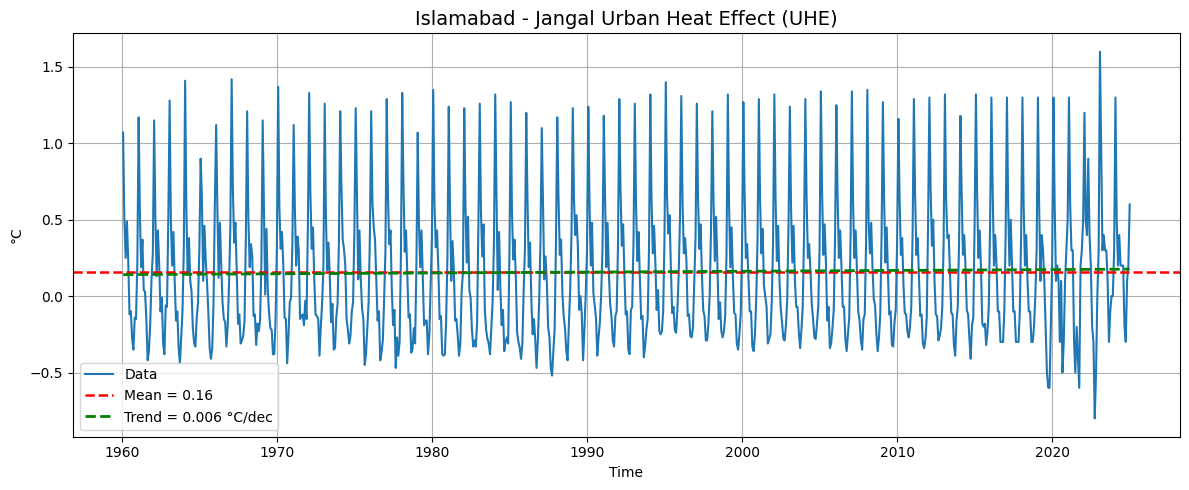

In [ ]:
# Example with your UHE series
uhe = tmin_i9_monthly - tmin_jangal_monthly
plot_series_with_trend(uhe, title="Urban Heat Effect (UHE)", ylabel="°C")


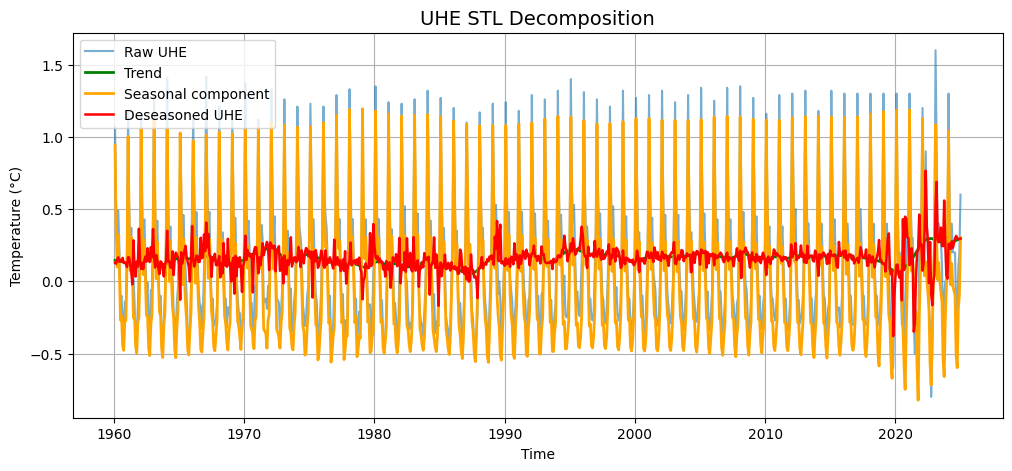

In [129]:

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# --- Example: your monthly UHE series ---
# uhe = tmin_i9_monthly - tmin_muhrain_monthly  # already monthly pd.Series

# --- STL decomposition ---
stl = STL(uhe.dropna(), period=12, robust=True)  # period=12 for monthly data
res = stl.fit()

# Extract components
trend = res.trend        # long-term trend
seasonal = res.seasonal  # seasonal cycle
residual = res.resid     # remaining noise

# Deseasonalized series (trend + residual)
uhe_deseasoned = uhe - seasonal

# --- Plotting ---
plt.figure(figsize=(12,5))
plt.plot(uhe, label='Raw UHE', alpha=0.6)
plt.plot(trend, label='Trend', color='green', linewidth=2)
plt.plot(seasonal, label='Seasonal component', color='orange', linewidth=2)
plt.plot(uhe_deseasoned, label='Deseasoned UHE', color='red', linewidth=1.8)
plt.title("UHE STL Decomposition", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


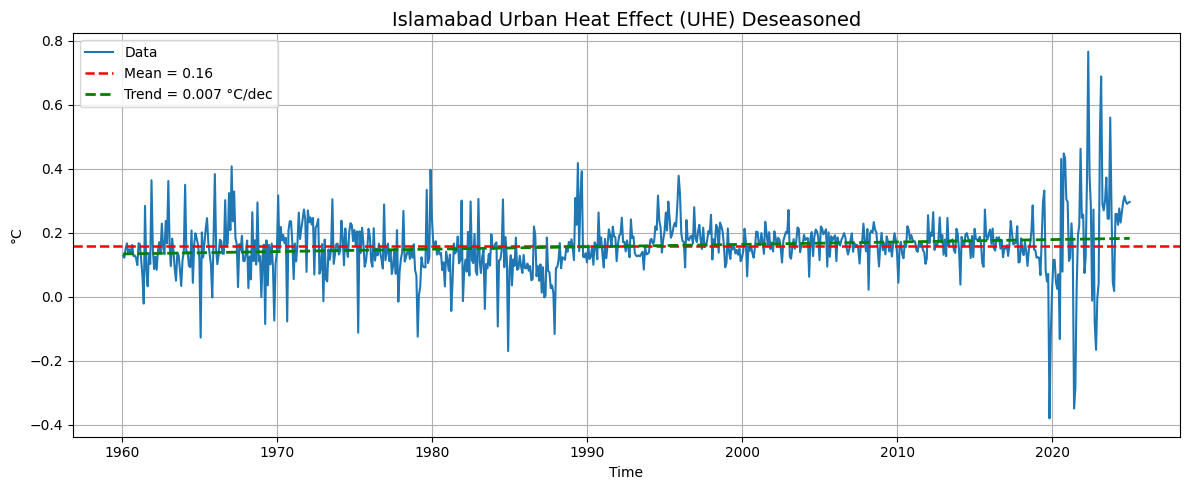

In [130]:
uhe_deseasoned = uhe - seasonal
plot_series_with_trend(uhe_deseasoned, title="Islamabad Urban Heat Effect (UHE) Deseasoned", ylabel="°C")


<Figure size 1200x400 with 0 Axes>

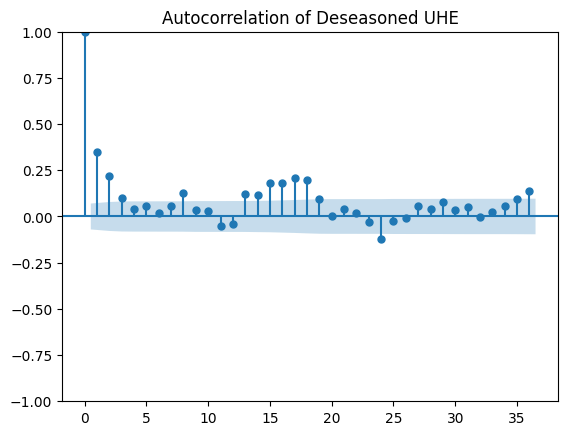

<Figure size 1200x400 with 0 Axes>

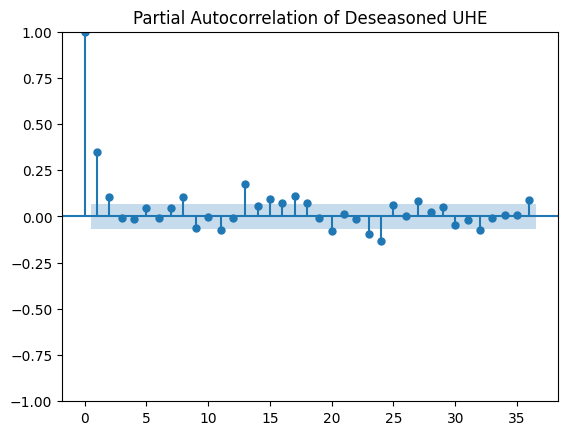

In [131]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(uhe_deseasoned.dropna(), lags=36)  # up to 3 years (36 months)
plt.title("Autocorrelation of Deseasoned UHE")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(uhe_deseasoned.dropna(), lags=36)
plt.title("Partial Autocorrelation of Deseasoned UHE")
plt.show()

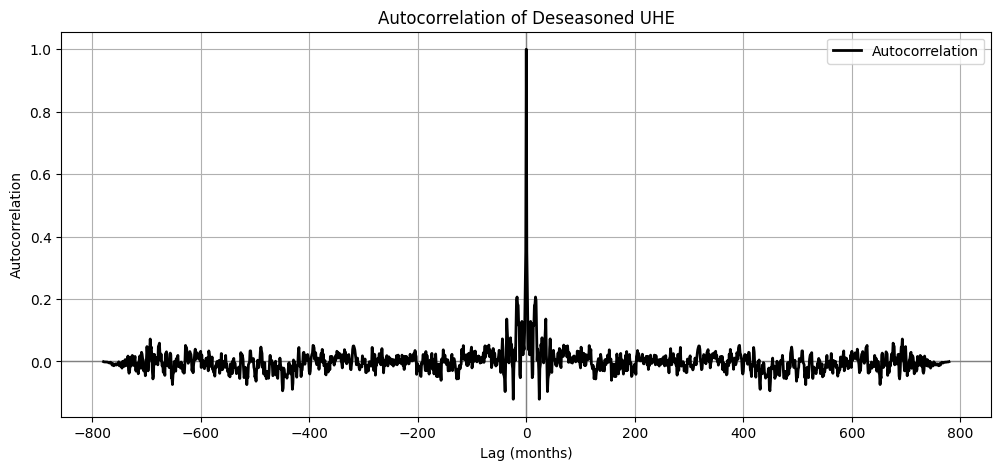

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# x = deseasoned UHE series (as np.array)
x = uhe_deseasoned.dropna().values

# subtract mean
x = x - np.mean(x)

# compute autocorrelation
acorr = np.correlate(x, x, mode='full') / np.sum(x**2)

# define lag array
lags = np.arange(-len(x)+1, len(x))

# plot
plt.figure(figsize=(12,5))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.plot(lags, acorr, color='k', linewidth=2, label='Autocorrelation')
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Deseasoned UHE")
plt.legend()
plt.grid(True)
plt.show()


In [133]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import numpy as np

# deseasoned UHE
y = uhe_deseasoned.values
x = np.arange(len(y))
x = sm.add_constant(x)

# fit linear trend
model = sm.OLS(y, x).fit()
print(model.summary())

# Durbin-Watson test
dw = durbin_watson(model.resid)
print("Durbin-Watson statistic:", dw)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     18.66
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           1.76e-05
Time:                        19:52:52   Log-Likelihood:                 766.14
No. Observations:                 780   AIC:                            -1528.
Df Residuals:                     778   BIC:                            -1519.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1340      0.006     20.650      0.0

In [134]:
x = uhe_deseasoned.dropna().values
r1 = np.corrcoef(x[:-1], x[1:])[0,1]
print("Lag-1 autocorrelation:", r1)


Lag-1 autocorrelation: 0.35206293911551034


In [135]:
N = len(x)
Ne = N * (1 - r1) / (1 + r1)
print("Effective sample size:", Ne)


Effective sample size: 373.7924418078625


In [136]:
t = np.arange(N)
slope, intercept = np.polyfit(t, x, 1)
resids = x - (slope*t + intercept)


In [137]:
std_err_ne = np.sqrt(np.sum(resids**2) / ((Ne - 2) * np.sum((t - t.mean())**2)))


In [138]:
from scipy import stats
t_crit_ne = stats.t.ppf(0.975, Ne-2)
ci_slope = t_crit_ne * std_err_ne
print("Slope +/- CI (°C/month):", slope, "+/-", ci_slope)


Slope +/- CI (°C/month): 6.232261017720113e-05 +/- 4.103906320840528e-05


In [139]:
import numpy as np
import pandas as pd
from scipy import stats



# Step 1: Length of series
N = len(uhe_deseasoned)

# Step 2: Compute lag-1 autocorrelation
lag1 = uhe_deseasoned.autocorr(lag=1)
print("Lag-1 autocorrelation:", lag1)

# Step 3: Effective sample size
Neff = 422.793470787957

# Step 4: Mean UHE
uhe_mean = uhe_deseasoned.mean()
print("Mean UHE (°C):", uhe_mean)

# Step 5: Standard error using Neff
std_dev = uhe_deseasoned.std(ddof=1)
SE = std_dev / np.sqrt(Neff)
print("Standard error (corrected for autocorrelation):", SE)

# Step 6: 95% confidence interval
df = Neff - 1
t_crit = stats.t.ppf(0.975, df)
CI = t_crit * SE
print("95% CI (°C): ±", CI)

# Step 7: t-test for mean != 0
t_stat = uhe_mean / SE
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
print("t-statistic:", t_stat)
print("p-value:", p_value)


Lag-1 autocorrelation: 0.35206293911551034
Mean UHE (°C): 0.15831196921236268
Standard error (corrected for autocorrelation): 0.004462191830353145
95% CI (°C): ± 0.008770902698512372
t-statistic: 35.47852159458452
p-value: 0.0


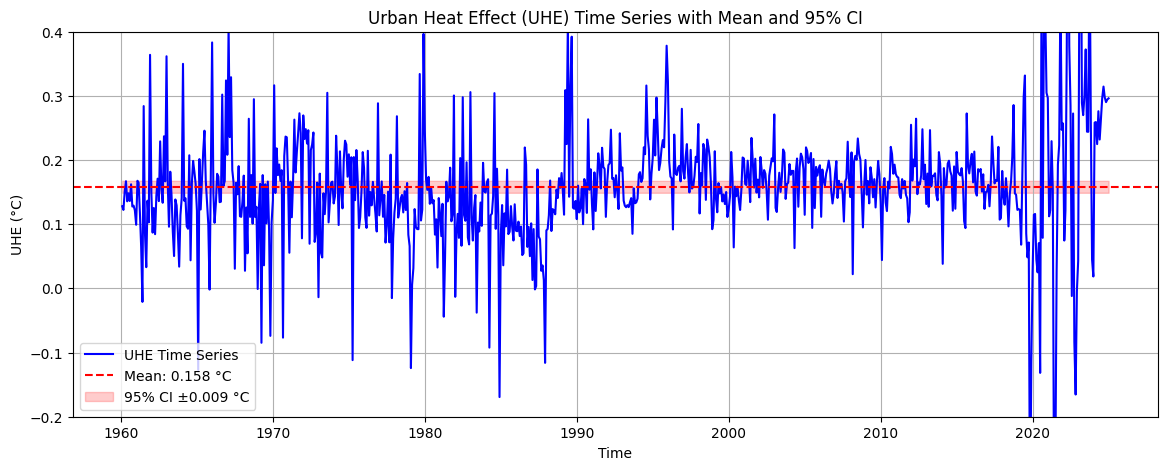

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats


# Step 1: Compute lag-1 autocorrelation and Neff
lag1 = uhe_deseasoned.autocorr(lag=1)
N = len(uhe_deseasoned)
Neff = N * (1 - lag1) / (1 + lag1)

# Step 2: Compute mean and standard error
uhe_mean = uhe_deseasoned.mean()
std_dev = uhe_deseasoned.std(ddof=1)
SE = std_dev / np.sqrt(Neff)

# Step 3: Compute 95% CI
df = Neff - 1
t_crit = stats.t.ppf(0.975, df)
CI = t_crit * SE

# Step 4: Plot
plt.figure(figsize=(14,5))
plt.plot(uhe_deseasoned.index, uhe_deseasoned, color='blue', label='UHE Time Series')
plt.axhline(uhe_mean, color='red', linestyle='--', label=f'Mean: {uhe_mean:.3f} °C')
plt.fill_between(uhe_deseasoned.index, uhe_mean - CI, uhe_mean + CI, color='red', alpha=0.2, label=f'95% CI ±{CI:.3f} °C')
plt.ylim(-0.2, 0.4)
plt.xlabel("Time")
plt.ylabel("UHE (°C)")
plt.title("Urban Heat Effect (UHE) Time Series with Mean and 95% CI")
plt.legend()
plt.grid(True)
plt.show()
